# Depth-window fixes: what changed and why

Three arms, same θ, same glaciers (Grenzgletscher + Glacier de Tête Rousse), spin-up on.

| arm | solver | stencil | `/2.` factor |
|---|---|---|---|
| `ab_explicit` | explicit | uniform-grid (old) | yes |
| `ab_implicit` | implicit | uniform-grid (old) | no |
| `ab_stencil` | implicit | non-uniform finite volume (new) | no |

The layer grid is 10×1 m, 10×5 m, 23×20 m. The old stencil used one layer's own thickness as the
distance to *both* neighbours, which is only correct when spacing is uniform — so it was wrong at
the 1→5 m and 5→20 m block edges, exactly where firn becomes ice.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from icetemp.io import read_profile_file   # handles the known header/data off-by-one

BASE = Path('../data/bayescal')
ARMS = {'explicit (old stencil)': 'ab_explicit_w0',
        'implicit (old stencil)': 'ab_implicit_w0',
        'implicit + new stencil': 'ab_stencil_w0'}
COLOR = dict(zip(ARMS, ['tab:gray', 'tab:blue', 'tab:red']))
SUB = 'training_runs/monthly/CentralEurope/PAST/firnice_temperature'


def read_profile(path):
    """-> (elevation, depths[n], T[n_months, n]); NODATA already NaN."""
    elev, depths, df = read_profile_file(path)
    if df.empty:
        return elev, np.asarray(depths, float), np.empty((0, len(depths)))
    T = df.drop(columns=['year', 'month']).to_numpy(dtype=float)
    return elev, np.asarray(depths, float), T


def load(arm_dir):
    d = BASE / arm_dir / SUB
    if not d.exists():
        return {}
    out = {}
    for f in sorted(d.glob('temp_ID*.dat')):
        try:
            elev, depths, T = read_profile(f)
            if T.size:
                out[f.name] = (elev, depths, T)
        except Exception as exc:
            print(f'  skipped {f.name}: {exc}')
    return out


data = {k: load(v) for k, v in ARMS.items()}
for k, v in data.items():
    n = len(v)
    print(f'{k:26s} {n:3d} profiles' + ('' if n else '   <-- run not finished yet'))
available = [k for k, v in data.items() if v]
common = sorted(set.intersection(*[set(data[k]) for k in available])) if available else []
print(f'\n{len(common)} profiles common to all available arms')

explicit (old stencil)      32 profiles
implicit (old stencil)      32 profiles
implicit + new stencil      32 profiles

32 profiles common to all available arms


## 1. The profiles themselves

Deepest-reaching bands, last simulated month.

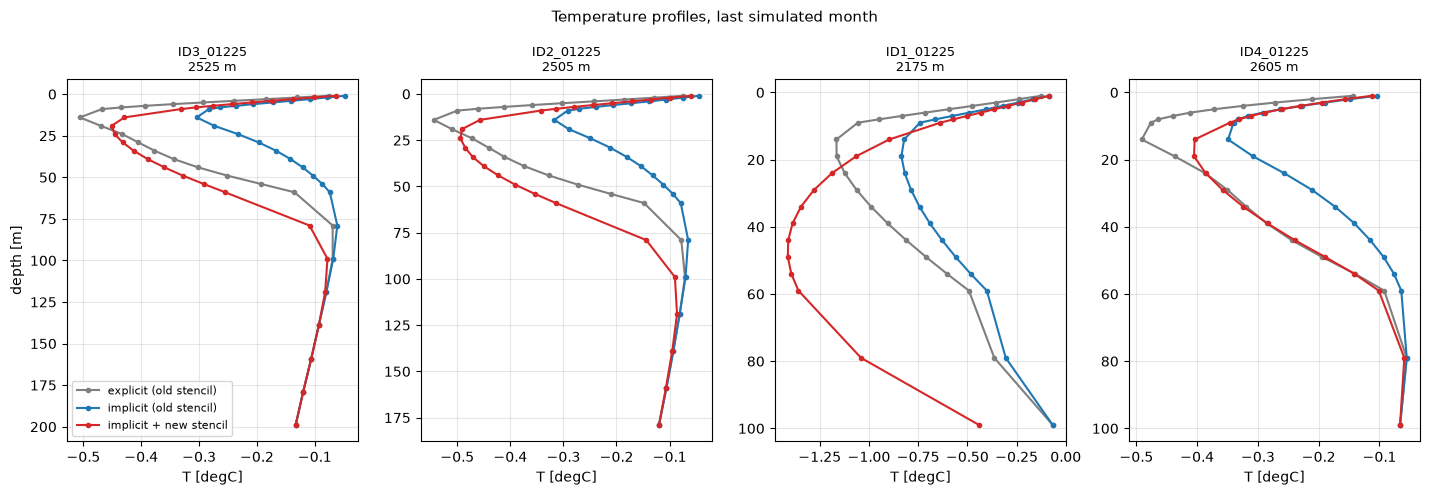

In [2]:
def deepest(files, n=4):
    def depth_of(fn):
        _, d, T = data[available[0]][fn]
        ok = np.isfinite(T[-1])
        return d[ok].max() if ok.any() else 0
    return sorted(files, key=depth_of, reverse=True)[:n]

sel = deepest(common, 4)
fig, axes = plt.subplots(1, len(sel), figsize=(3.6 * len(sel), 5), sharey=False)
axes = np.atleast_1d(axes)
for ax, fn in zip(axes, sel):
    for arm in available:
        elev, d, T = data[arm][fn]
        prof = T[-1]
        ok = np.isfinite(prof)
        ax.plot(prof[ok], d[ok], 'o-', ms=3, lw=1.5, color=COLOR[arm], label=arm)
    ax.invert_yaxis()
    ax.set_title(f'{fn.replace("temp_", "").replace(".dat", "")}\n{elev:.0f} m', fontsize=9)
    ax.set_xlabel('T [degC]')
    ax.grid(alpha=.3)
axes[0].set_ylabel('depth [m]')
axes[0].legend(fontsize=8)
fig.suptitle('Temperature profiles, last simulated month', fontsize=11)
fig.tight_layout()

## 2. How much each change moved the model

Against the three parameters, which move it ~1.2 °C per standard deviation.

In [3]:
rows = []
for fn in common:
    prof = {arm: data[arm][fn][2][-1] for arm in available}
    ok = np.all([np.isfinite(p) for p in prof.values()], axis=0)
    if ok.sum() == 0:
        continue
    r = {'profile': fn.replace('temp_', '').replace('.dat', ''),
         'elev': data[available[0]][fn][0], 'n_nodes': int(ok.sum())}
    if 'implicit (old stencil)' in prof and 'explicit (old stencil)' in prof:
        r['solver |d| max'] = np.abs(prof['implicit (old stencil)'][ok]
                                     - prof['explicit (old stencil)'][ok]).max()
    if 'implicit + new stencil' in prof and 'implicit (old stencil)' in prof:
        r['stencil |d| max'] = np.abs(prof['implicit + new stencil'][ok]
                                      - prof['implicit (old stencil)'][ok]).max()
    rows.append(r)

diffs = pd.DataFrame(rows).sort_values('elev')
display(diffs.round(3))
for c in ('solver |d| max', 'stencil |d| max'):
    if c in diffs:
        print(f'{c:18s} median {diffs[c].median():5.2f}   max {diffs[c].max():5.2f} degC')
print('\nfor scale: f_ref 1.20, f_ins 0.92, f_adv 0.15 degC per 1 sd (firn bands)')

,profile,elev,n_nodes,solver |d| max,stencil |d| max
11,ID1_01225,2175,21,0.344,0.957
17,ID2_01225,2505,25,0.230,0.296
20,ID3_01225,2525,26,0.210,0.247
22,ID4_01225,2605,21,0.146,0.151
10,ID1_00777,3135,11,0.039,0.066
16,ID2_00777,3145,12,0.034,0.044
19,ID3_00777,3155,12,0.018,0.012
21,ID4_00777,3165,13,0.023,0.012
23,ID5_00777,3175,13,0.023,0.012
25,ID6_00777,3185,12,0.018,0.011


solver |d| max     median  0.29   max  3.41 degC
stencil |d| max    median  0.54   max  6.15 degC

for scale: f_ref 1.20, f_ins 0.92, f_adv 0.15 degC per 1 sd (firn bands)


## 3. The stencil tell

Temperature gradient between adjacent nodes. The old scheme made the steady profile linear in
layer **index** rather than in depth, so the gradient jumped by the block ratio (5× at 9→14 m,
4× at 59→79 m). A correct scheme gives a gradient that varies smoothly with depth.

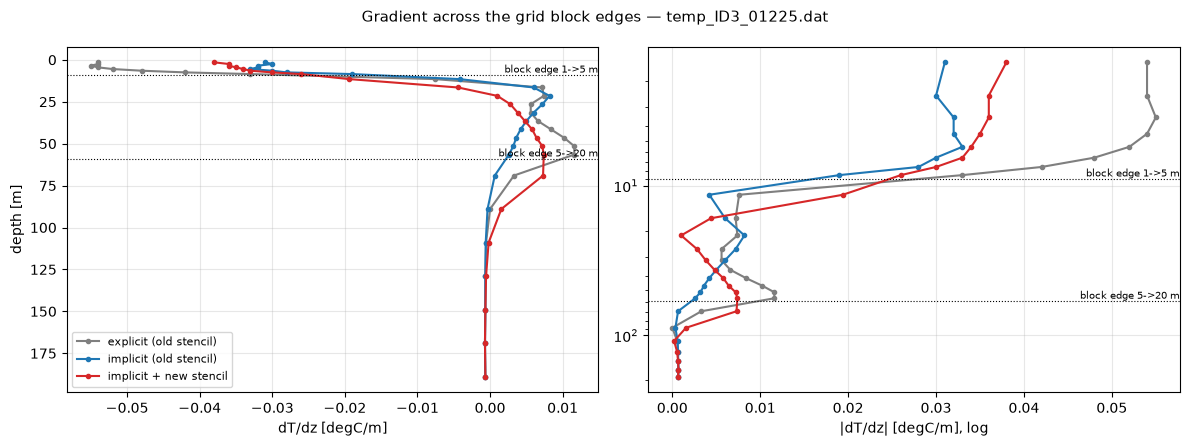

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fn = sel[0]
for arm in available:
    elev, d, T = data[arm][fn]
    prof = T[-1]
    ok = np.isfinite(prof)
    dd, pp = d[ok], prof[ok]
    grad = np.diff(pp) / np.diff(dd)
    mid = 0.5 * (dd[1:] + dd[:-1])
    axes[0].plot(grad, mid, 'o-', ms=3, color=COLOR[arm], label=arm)
    axes[1].semilogy(np.abs(grad) + 1e-6, mid, 'o-', ms=3, color=COLOR[arm], label=arm)
for ax, lab in zip(axes, ['dT/dz [degC/m]', '|dT/dz| [degC/m], log']):
    for z, s in [(9, '1->5 m'), (59, '5->20 m')]:
        ax.axhline(z, color='k', ls=':', lw=.8)
        ax.text(ax.get_xlim()[1], z, f' block edge {s}', fontsize=7, va='bottom', ha='right')
    ax.invert_yaxis()
    ax.set_xlabel(lab)
    ax.grid(alpha=.3)
axes[0].set_ylabel('depth [m]')
axes[0].legend(fontsize=8)
fig.suptitle(f'Gradient across the grid block edges — {fn}', fontsize=11)
fig.tight_layout()

## 3b. The decisive stencil test

Figure 3 above is a weak test: near the surface the gradient is dominated by the seasonal wave,
which is genuinely steep, and 200 spin-up cycles is too short to build a geothermal gradient at
depth. So neither end of a real profile isolates the numerical error.

This does. Both stencils are solved to steady state on the real grid with uniform conductivity,
a fixed surface temperature and the model's own geothermal bed condition — a case with an exact
analytical answer: the profile must be linear in DEPTH with slope G/k.

,stencil,1 m block,5 m block,20 m block,bed T [degC]
0,old,0.5714,0.1143,0.0286,14.0000
1,new,0.0286,0.0286,0.0286,4.8286
2,analytical,0.0286,0.0286,0.0286,4.8286


The old scheme is 20x too steep in the 1 m block and 4x in the 5 m block -- exactly the
grid-spacing ratios. Its bed temperature is +14.0 degC where the physics gives +4.8 degC.
In the real model the PMP clamp hides that error by capping at the melting point.


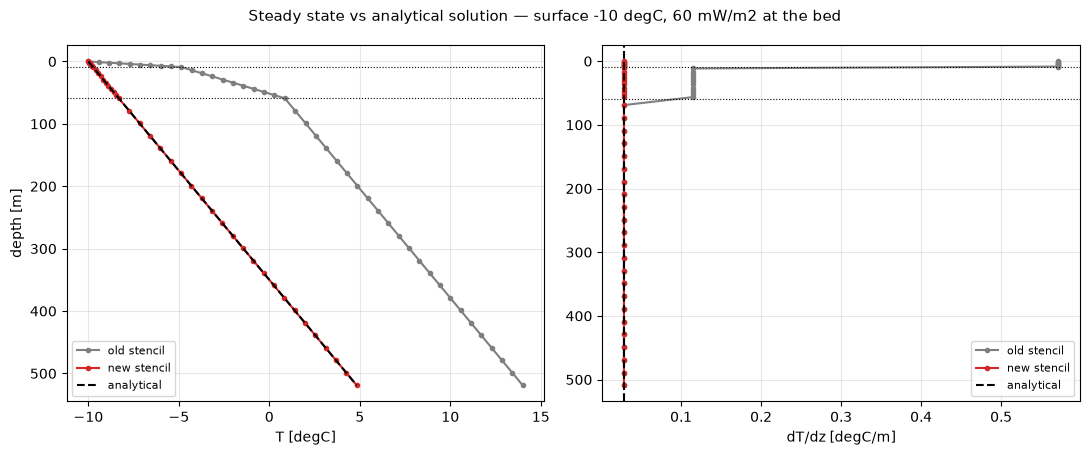

In [5]:
dz_g = np.concatenate([np.full(10, 1.), np.full(10, 5.), np.full(23, 20.)])
z_g = np.concatenate([[0.], np.cumsum(dz_g[1:])])
n_g, k_g, G_g, Ts_g = len(z_g), 2.1, 0.06, -10.0


def steady(stencil):
    """Exact steady-state solve of the tridiagonal system for one stencil."""
    m = n_g - 1
    A = np.zeros((m, m)); b = np.zeros(m)
    for j in range(1, n_g - 1):
        r = j - 1
        if stencil == 'old':                      # r cancels -> T[j-1]-2T[j]+T[j+1]=0
            cm, cc, cp = 1., -2., 1.
        else:                                     # flux continuity, non-uniform spacing
            dzm, dzp = dz_g[j], dz_g[min(j + 1, n_g - 1)]
            cm, cp = 1. / dzm, 1. / dzp
            cc = -(cm + cp)
        if j - 1 == 0:
            b[r] -= cm * Ts_g
        else:
            A[r, j - 2] = cm
        A[r, r] = cc
        A[r, j] = cp
    A[m - 1, :] = 0.; A[m - 1, m - 1] = 1.; A[m - 1, m - 2] = -1.
    b[m - 1] = G_g * dz_g[n_g - 1] / k_g
    return np.concatenate([[Ts_g], np.linalg.solve(A, b)])


exact = Ts_g + (G_g / k_g) * z_g
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for nm, col in [('old', 'tab:gray'), ('new', 'tab:red')]:
    T = steady(nm)
    axes[0].plot(T, z_g, 'o-', ms=3, color=col, label=f'{nm} stencil')
    axes[1].plot(np.diff(T) / np.diff(z_g), .5 * (z_g[1:] + z_g[:-1]), 'o-', ms=3, color=col,
                 label=f'{nm} stencil')
axes[0].plot(exact, z_g, 'k--', lw=1.5, label='analytical')
axes[1].axvline(G_g / k_g, color='k', ls='--', lw=1.5, label='analytical')
for ax, xl in zip(axes, ['T [degC]', 'dT/dz [degC/m]']):
    for zz in (9, 59):
        ax.axhline(zz, color='k', ls=':', lw=.8)
    ax.invert_yaxis(); ax.set_xlabel(xl); ax.grid(alpha=.3); ax.legend(fontsize=8)
axes[0].set_ylabel('depth [m]')
fig.suptitle('Steady state vs analytical solution — surface -10 degC, 60 mW/m2 at the bed',
             fontsize=11)
fig.tight_layout()

rows = []
for nm in ('old', 'new'):
    T = steady(nm); g = np.diff(T) / np.diff(z_g)
    rows.append({'stencil': nm, '1 m block': g[1:9].mean(), '5 m block': g[10:19].mean(),
                 '20 m block': g[20:].mean(), 'bed T [degC]': T[-1]})
rows.append({'stencil': 'analytical', '1 m block': G_g / k_g, '5 m block': G_g / k_g,
             '20 m block': G_g / k_g, 'bed T [degC]': exact[-1]})
display(pd.DataFrame(rows).round(4))
print('The old scheme is 20x too steep in the 1 m block and 4x in the 5 m block -- exactly the')
print('grid-spacing ratios. Its bed temperature is +14.0 degC where the physics gives +4.8 degC.')
print('In the real model the PMP clamp hides that error by capping at the melting point.')

## 4. Spin-up convergence

How fast the deep column settles. Halving the diffusivity slowed this down.

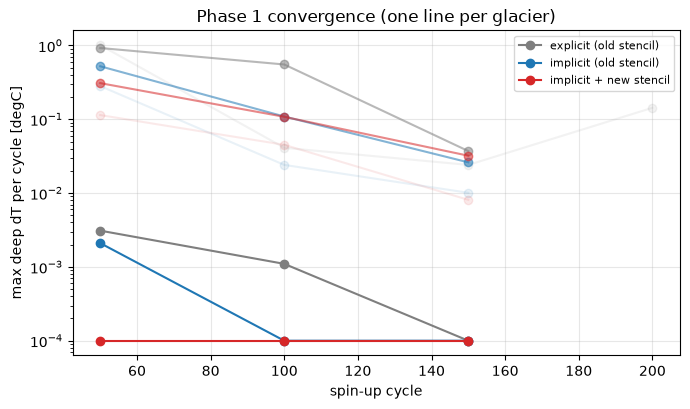

In [6]:
pat = re.compile(r'cycle\s+(\d+)\s+max deep .T =\s+([0-9.]+)')
fig, ax = plt.subplots(figsize=(7, 4.2))
for arm, tag in ARMS.items():
    log = BASE / tag / 'training_runs' / 'design_0000.log'
    if not log.exists():
        continue
    runs, cur = [], []
    for ln in log.read_text(errors='ignore').splitlines():
        if 'Phase 1: equilibrium' in ln:
            if cur:
                runs.append(cur)
            cur = []
        mm = pat.search(ln)
        if mm:
            cur.append((int(mm.group(1)), float(mm.group(2))))
    if cur:
        runs.append(cur)
    for k, r in enumerate(runs):
        if not r:
            continue
        c, v = zip(*r)
        ax.semilogy(c, np.array(v) + 1e-4, 'o-', color=COLOR[arm], alpha=1 - 0.45 * k,
                    label=f'{arm}' if k == 0 else None)
ax.set_xlabel('spin-up cycle')
ax.set_ylabel('max deep dT per cycle [degC]')
ax.set_title('Phase 1 convergence (one line per glacier)')
ax.legend(fontsize=8)
ax.grid(alpha=.3)
fig.tight_layout()

## 5. The depth window

How much of the glenglat data the model can actually see. This is what the whole plan is about:
the model resolves a median of 44 m against boreholes reaching 348 m.

In [7]:
import subprocess, sys
# reuse the committed script rather than duplicating its logic here
print(subprocess.run([sys.executable, 'scripts/icetemp_analysis/depth_window.py'],
                     cwd='..', capture_output=True, text=True,
                     env={'PYTHONPATH': 'src', 'PATH': '/usr/bin:/bin'}).stdout or
      'run manually: PYTHONPATH=src python scripts/icetemp_analysis/depth_window.py')

Calibration glaciers: 116 (equilibrium=true: 56, estimated: 36, unassessed/blank: 24)
  with accumulation-zone (firn) obs: 89
  with ablation-zone (ice) obs:      27
  with data below 30 m:              37
  largest depth-bin pooling factor:  40776 raw readings -> 1 point (continuous-logger dedup)
Prediction (all glenglat) glaciers:  211
entities: 66
modelled resolved depth: median 44 m, p25 34 m, max 179 m
observed depth:          median 21 m, max 348 m

OBSERVATIONS: 538 of 776 within the modelled column (69%), 238 below it
entities where the borehole is deeper than the model: 25/66

per glacier:
                        n_ent  obs  visible  lost  z_model  z_obs
glacier                                                          
Glacier de Tête Rousse      8  106       18    88     19.0   70.0
Glacier des Bossons        15  124       80    44     49.0  125.6
Gornergletscher             3   48       29    19    139.0  347.7
Grenzgletscher             24  376      301    75     44.0  347.

## What to look for

| figure | the thing that matters |
|---|---|
| 1 | profiles should stay physical — no oscillation, nothing outside about −25…0 °C |
| 2 | both changes move the model more than the calibration parameters do |
| 3 | old arms kink at the block edges; the new stencil should not |
| 4 | implicit reaches equilibrium in fewer cycles |
| 5 | how many observations are still below the modelled column |